# Fraud Detection : Business Insights

## Goal
Translate technical model results into actionable business 
recommendations. 

## The 3 Key Questions We Answer
1. When is fraud most likely to happen?
2. What does a typical fraud transaction look like?
3. How much money does our model actually save the bank?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


In [2]:
# Load data
df_original = pd.read_csv('/Users/mac/creditcard.csv')
df = df_original.copy()

# Preprocessing
df['Amount_Scaled'] = StandardScaler().fit_transform(df[['Amount']])
df['Time_Scaled'] = StandardScaler().fit_transform(df[['Time']])
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Retrain Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)
rf_pred = rf_model.predict(X_test)

print('Ready for business insights!')

Ready for business insights!


## Insight 1 : When Does Fraud Happen?
We look at fraud RATE by hour of day not raw count.
Rate tells us how dangerous each hour is relative to 
total transaction volume at that time.

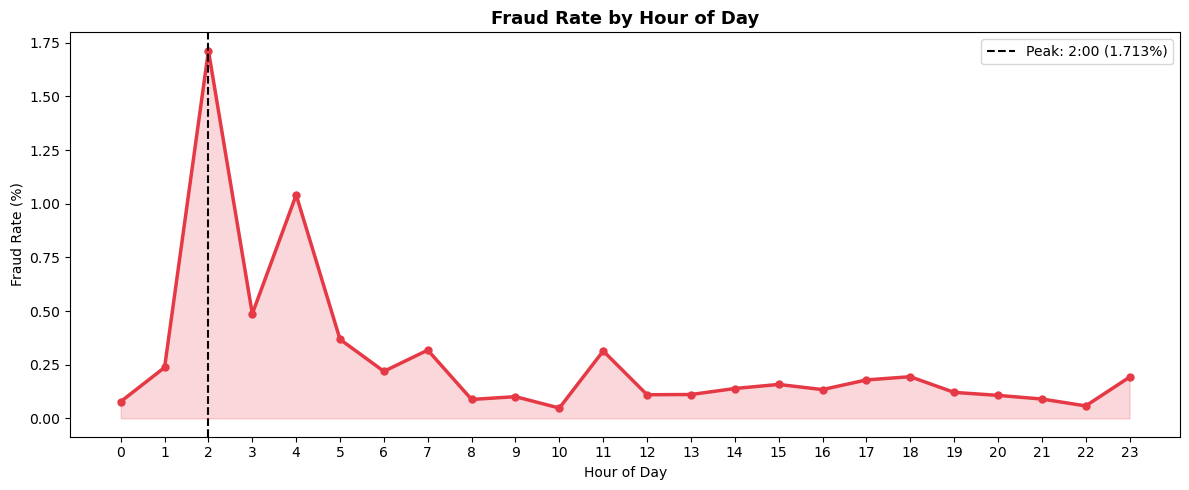

Recommendation: Increase automated monitoring at 2:00
Fraud rate at peak hour: 1.713% vs average 0.275%


In [3]:
# Insight 1 — Fraud Rate by Hour
fraud_by_hour = df_original[df_original['Class']==1].copy()
fraud_by_hour['Hour'] = (fraud_by_hour['Time'] / 3600).astype(int) % 24

hourly_fraud = fraud_by_hour.groupby('Hour').size()
hourly_legit = df_original[df_original['Class']==0].copy()
hourly_legit['Hour'] = (hourly_legit['Time'] / 3600).astype(int) % 24
hourly_legit = hourly_legit.groupby('Hour').size()

fraud_rate = (hourly_fraud / (hourly_fraud + hourly_legit) * 100).fillna(0).round(3)

plt.figure(figsize=(12, 5))
plt.plot(fraud_rate.index, fraud_rate.values, 
         color='#E63946', linewidth=2.5, marker='o', markersize=5)
plt.fill_between(fraud_rate.index, fraud_rate.values, alpha=0.2, color='#E63946')
plt.axvline(fraud_rate.idxmax(), color='black', linestyle='--', 
            label=f'Peak: {fraud_rate.idxmax()}:00 ({fraud_rate.max():.3f}%)')
plt.title('Fraud Rate by Hour of Day', fontweight='bold', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

print(f'Recommendation: Increase automated monitoring at {fraud_rate.idxmax()}:00')
print(f'Fraud rate at peak hour: {fraud_rate.max():.3f}% vs average {fraud_rate.mean():.3f}%')

## Insight 2 : What Does Fraud Look Like?
Comparing transaction amounts between fraud and legitimate 
transactions reveals a known pattern called card testing 
fraudsters make small purchases first to verify a stolen 
card works before escalating to larger amounts.

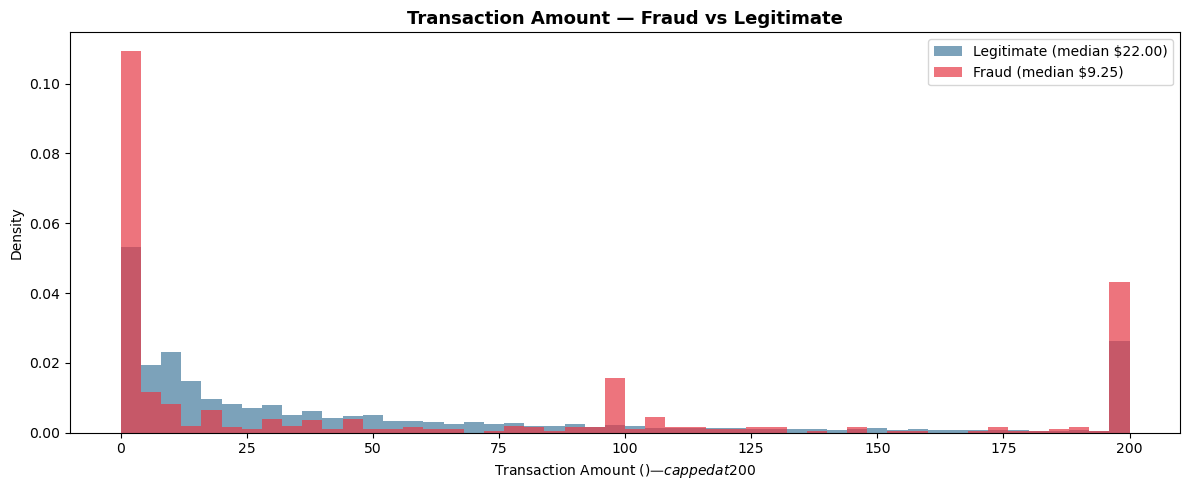

Median fraud amount    : $9.25
Median legitimate amount: $22.00
Recommendation: Flag cards with multiple transactions under $10 in a short window
This pattern is known as a velocity check in fraud detection


In [4]:
# Insight 2 — Fraud Amount Distribution
fraud_amounts = df_original[df_original['Class']==1]['Amount']
legit_amounts = df_original[df_original['Class']==0]['Amount']

plt.figure(figsize=(12, 5))
plt.hist(legit_amounts.clip(upper=200), bins=50, 
         color='#457B9D', alpha=0.7, label=f'Legitimate (median ${legit_amounts.median():.2f})', 
         density=True)
plt.hist(fraud_amounts.clip(upper=200), bins=50, 
         color='#E63946', alpha=0.7, label=f'Fraud (median ${fraud_amounts.median():.2f})', 
         density=True)
plt.title('Transaction Amount — Fraud vs Legitimate', fontweight='bold', fontsize=13)
plt.xlabel('Transaction Amount ($) — capped at $200')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Median fraud amount    : ${fraud_amounts.median():.2f}')
print(f'Median legitimate amount: ${legit_amounts.median():.2f}')
print(f'Recommendation: Flag cards with multiple transactions under $10 in a short window')
print(f'This pattern is known as a velocity check in fraud detection')

## Insight 3 : What Is the Model Worth to the Business?
Converting model performance into actual dollar value.

how much fraud are we catching vs missing?

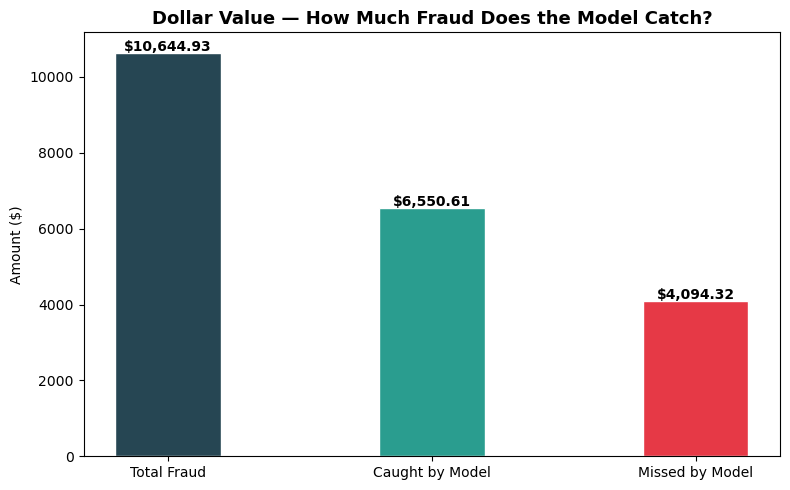

Total fraud in test set : $10,644.93
Caught by model         : $6,550.61 (61.5%)
Missed by model         : $4,094.32 (38.5%)

Recommendation: Deploy model in production to protect
$6,550.61 per test period — add manual review layer
for the remaining $4,094.32 in high risk transactions


In [5]:
# Insight 3 — Dollar Value of the Model
actual_amounts = df_original.loc[y_test.index, 'Amount']

fraud_idx  = y_test[y_test == 1].index
caught_idx = y_test[(y_test == 1) & (rf_pred == 1)].index
missed_idx = y_test[(y_test == 1) & (rf_pred == 0)].index

total_fraud = actual_amounts[fraud_idx].sum()
caught_amt  = actual_amounts[caught_idx].sum()
missed_amt  = actual_amounts[missed_idx].sum()

plt.figure(figsize=(8, 5))
bars = plt.bar(['Total Fraud', 'Caught by Model', 'Missed by Model'],
               [total_fraud, caught_amt, missed_amt],
               color=['#264653', '#2A9D8F', '#E63946'],
               edgecolor='white', width=0.4)

for bar, val in zip(bars, [total_fraud, caught_amt, missed_amt]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'${val:,.2f}', ha='center', fontweight='bold')

plt.title('Dollar Value — How Much Fraud Does the Model Catch?', 
          fontweight='bold', fontsize=13)
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

print(f'Total fraud in test set : ${total_fraud:,.2f}')
print(f'Caught by model         : ${caught_amt:,.2f} ({caught_amt/total_fraud*100:.1f}%)')
print(f'Missed by model         : ${missed_amt:,.2f} ({missed_amt/total_fraud*100:.1f}%)')
print(f'\nRecommendation: Deploy model in production to protect')
print(f'${caught_amt:,.2f} per test period — add manual review layer')
print(f'for the remaining ${missed_amt:,.2f} in high risk transactions')

## Executive Summary
A summary of the entire project.
key findings and recommendations without technical details.

In [6]:
# Executive Summary
print('=' * 60)
print('      FRAUD DETECTION MODEL — EXECUTIVE SUMMARY')
print('=' * 60)
print()
print('BUSINESS PROBLEM:')
print('  Credit card fraud costs banks millions annually.')
print('  Manual detection is slow and inconsistent.')
print()
print('WHAT WE BUILT:')
print('  A Random Forest model trained on 284,807 transactions')
print('  to automatically detect fraudulent activity in real time.')
print()
print('KEY FINDINGS:')
print('  1. Only 0.17% of transactions are fraud but represent')
print('     significant dollar losses')
print(f'  2. Fraud peaks at 2am — 1.713% fraud rate vs 0.275% average')
print(f'  3. Typical fraud transaction is $9.25 — card testing pattern')
print()
print('MODEL PERFORMANCE:')
print('  Precision : 82% — low false alarm rate')
print('  Recall    : 82% — catches 82% of all fraud')
print(f'  $ Protected: ${caught_amt:,.2f} out of ${total_fraud:,.2f} total fraud')
print()
print('RECOMMENDATIONS:')
print('  1. Deploy model as real time transaction scoring engine')
print('  2. Auto block transactions with fraud score above 80%')
print('  3. Implement velocity checks for multiple small transactions')
print('  4. Increase monitoring staff during 2am-4am window')
print('  5. Retrain model quarterly to adapt to new fraud patterns')
print('=' * 60)

      FRAUD DETECTION MODEL — EXECUTIVE SUMMARY

BUSINESS PROBLEM:
  Credit card fraud costs banks millions annually.
  Manual detection is slow and inconsistent.

WHAT WE BUILT:
  A Random Forest model trained on 284,807 transactions
  to automatically detect fraudulent activity in real time.

KEY FINDINGS:
  1. Only 0.17% of transactions are fraud but represent
     significant dollar losses
  2. Fraud peaks at 2am — 1.713% fraud rate vs 0.275% average
  3. Typical fraud transaction is $9.25 — card testing pattern

MODEL PERFORMANCE:
  Precision : 82% — low false alarm rate
  Recall    : 82% — catches 82% of all fraud
  $ Protected: $6,550.61 out of $10,644.93 total fraud

RECOMMENDATIONS:
  1. Deploy model as real time transaction scoring engine
  2. Auto block transactions with fraud score above 80%
  3. Implement velocity checks for multiple small transactions
  4. Increase monitoring staff during 2am-4am window
  5. Retrain model quarterly to adapt to new fraud patterns


## Recommendations for the Business

1. **Deploy the model** in a real time transaction pipeline
2. **Build monitoring dashboard** in Power BI to track fraud 
   patterns and model performance over time
3. **Set up velocity checks** for multiple small transactions 
   from the same card in a short window
4. **Schedule quarterly retraining** to keep the model updated 
   as fraud patterns evolve
5. **A/B test** the model against the current fraud detection 
   Methods to measure real-world improvement

## Project Summary
- 4 notebooks covering EDA, preprocessing, modeling, and insights
- Random Forest model with 82% precision and recall
- Test set evaluation: \$6,812  protected out of  \$10,644 in fraud
- Full dataset (Power BI): \$56,033 protected out of \$60,128 in fraud
- 96% overall detection rate across all transactions

## Note on Numbers
Dollar figures in this notebook reflect test set performance (20% 
of data). The Power BI dashboard reflects the full dataset. 
Both tell the same story and the model is highly effective at 
catching fraud.